In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [198]:
df = pd.read_csv("WH_Data.csv")


In [199]:
df.head()

,Height,Weight
0,150,48
1,152,55
2,154,50
3,156,60
4,158,54


Text(0, 0.5, 'Height')

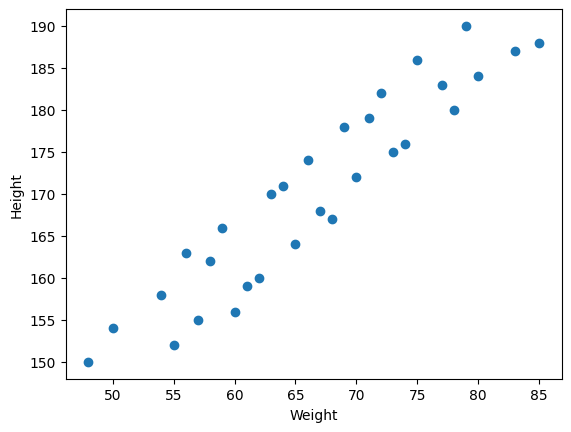

In [200]:
plt.scatter(df["Weight"],df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")

In [201]:
df.corr()

,Height,Weight
Height,1.000000,0.938791
Weight,0.938791,1.000000


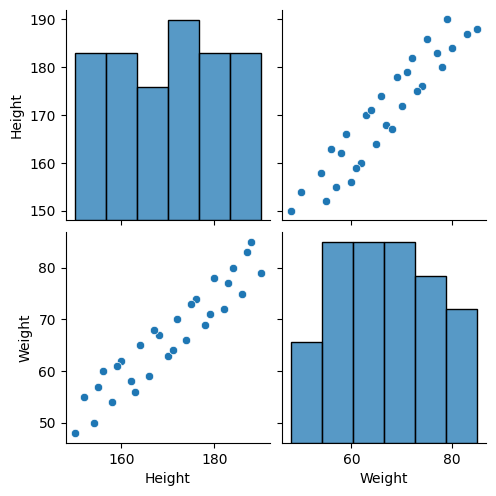

In [202]:
import seaborn as sns
sns.pairplot(df)

In [203]:
## Independent and dependent features
X = df[['Weight']]
y=df['Height']
np.array(X).shape


(30, 1)

In [204]:
X_series = df['Weight']
np.array(X_series).shape

(30,)

In [205]:
np.array(y).shape

(30,)

In [206]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [207]:
X_train.shape

(22, 1)

In [208]:
## Standardization
from sklearn.preprocessing import StandardScaler


In [209]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

In [210]:
X_test = scaler.transform(X_test)

In [211]:
X_test

array([[ 0.54699493],
       [ 1.25487071],
       [-0.96988176],
       [ 1.45712094],
       [-0.66650642],
       [ 0.14249448],
       [ 1.1537456 ],
       [ 0.24361959]])

In [212]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression


In [213]:
regression = LinearRegression(n_jobs=-1)


In [214]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [215]:
print("coefficient or slope : " ,regression.coef_)
print("Intercept: ",regression.intercept_)

coefficient or slope :  [11.73699004]
Intercept:  169.04545454545453


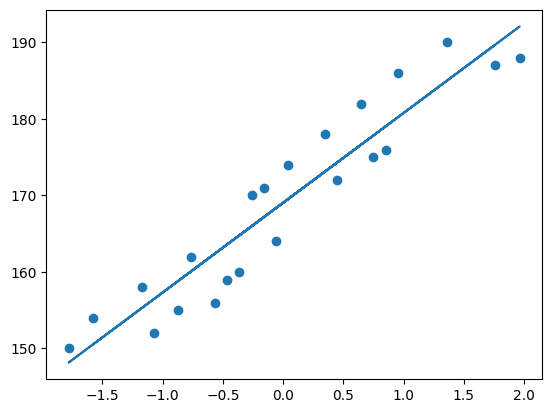

In [216]:
## plot training data plot best fit line

plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [217]:
## Prediction for test data
y_pred=regression.predict(X_test)

In [218]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [219]:
mse= mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

14.284915340274026
3.450891630923959
3.779539038067212


In [220]:
from sklearn.metrics import r2_score


In [221]:
score = r2_score(y_test,y_pred)
print(score)

0.7765800142283632


In [222]:
## display adjusted R-squared

1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7393433499330904

In [223]:
## OLS Linear Regression
import statsmodels.api as sm

In [224]:
model = sm.OLS(y_train,X_train).fit()

In [225]:
prediction=model.predict(X_test)
print(prediction)

[  6.42007399  14.72840503 -11.38349253  17.1022139   -7.82277923
   1.67245625  13.5415006    2.85936068]


In [226]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.005
Model:                            OLS   Adj. R-squared (uncentered):             -0.043
Method:                 Least Squares   F-statistic:                             0.1012
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                       0.754
Time:                        22:48:21   Log-Likelihood:                         -144.09
No. Observations:                  22   AIC:                                      290.2
Df Residuals:                      21   BIC:                                      291.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [227]:
## Prediction for new data
regression.predict(scaler.transform([[72]]))

s:\AIML Courses\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([176.65243297])